In [28]:
import pandas as pd
import sys
sys.path.append('/home/azureuser/cloudfiles/code/Users/manhductranvu/reeval-multi/mirt-official')
from load_params import load_and_rotate

resmat = pd.read_pickle("../data/resmat.pkl")

theta, a_init, b = load_and_rotate(rotation='varimax')

a_df = pd.DataFrame(a_init, index=resmat.columns)
theta_df = pd.DataFrame(theta, index=resmat.index)

/Users/ronan/Developer/reeval-multi/mirt-official/load_params.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_data = torch.load(model_path, map_location=torch.dev

--- Initial Loaded Data ---
Original theta shape: torch.Size([183, 19])
Original 'a' matrix shape: torch.Size([78712, 19])

--- After Rotation of 'a' ---
Rotated 'a' matrix shape: (78712, 19)

--- After Transformation of 'theta' ---
Transformed theta shape: (183, 19)

--- Final Standardized Z-Scores (from transformed theta) ---
These are the scores you should use for interpretation.
[[ 1.36679121 -1.29142072  0.02368664 ...  0.5948743   1.20452549
  -1.32143699]
 [ 0.8694796   0.65897874 -2.01923406 ... -0.49557078  1.18055759
  -1.37415132]
 [ 1.82481648 -1.4122685  -0.51204663 ...  0.78741921 -0.97111116
  -1.49879246]
 ...
 [-0.9912067  -0.93205986 -0.40201418 ...  0.99411487 -0.17602767
   1.24166521]
 [-0.71577314 -0.59205097 -0.52410342 ...  1.13348854 -0.10466067
   0.66230223]
 [ 0.18720646 -0.9709694   0.55470963 ...  0.3900838   1.68143397
  -0.28299898]]


# BIC analysis

Standardizing data...
Running GMM with BIC to find the optimal number of clusters...


Fitting GMMs:   0%|                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             | 0/40 [00:00<?, ?it/s]

Fitting GMMs: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [21:25<00:00, 32.13s/it]



Best number of clusters by BIC: 12


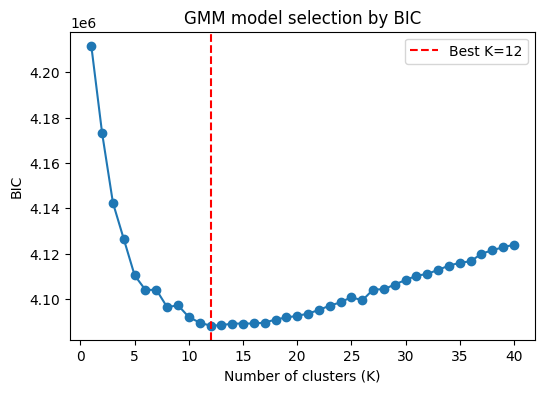

Saving results to CSV files...
Cluster assignments saved to item_clusters.csv
Cluster centroids saved to cluster_centroids.csv


In [ ]:
import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from tqdm import tqdm  # Import tqdm

# Assuming a_init and a_df are defined elsewhere
# Example placeholder data:
# a_init = np.random.rand(100, 10)
# a_df = pd.DataFrame(a_init, index=[f"item_{i}" for i in range(100)])


# ------------------- 1. Standardize -------------------
print("Standardizing data...")
X = StandardScaler().fit_transform(a_init)

# ------------------- 2. GMM with BIC -------------------
print("Running GMM with BIC to find the optimal number of clusters...")
Kmax = 40
bics = []
gmm_models = []
labels_list = []

# Wrap the range object with tqdm to create a progress bar
for K in tqdm(range(1, Kmax + 1), desc="Fitting GMMs"):
    gm = GaussianMixture(n_components=K, covariance_type='full', random_state=0)
    gm.fit(X)
    bics.append(gm.bic(X))
    gmm_models.append(gm)
    labels_list.append(gm.predict(X))

best_idx = int(np.argmin(bics))
best_K = best_idx + 1
best_model = gmm_models[best_idx]
best_labels = labels_list[best_idx]

print(f"\nBest number of clusters by BIC: {best_K}")

# ------------------- 3. Plot BIC curve -------------------
plt.figure(figsize=(6, 4))
plt.plot(range(1, Kmax + 1), bics, marker='o')
plt.axvline(best_K, color='r', linestyle='--', label=f'Best K={best_K}')
plt.xlabel("Number of clusters (K)")
plt.ylabel("BIC")
plt.legend()
plt.title("GMM model selection by BIC")
plt.show()

# ------------------- 4. Save results -------------------
print("Saving results to CSV files...")
# Add cluster labels to your items
clustered_df = pd.DataFrame({
    "item": a_df.index,
    "cluster": best_labels
})
clustered_df.to_csv("../result/item_clusters.csv", index=False)

# Compute cluster centroids (prototype skills)
centroids = pd.DataFrame(
    best_model.means_,
    columns=[f"dim_{i}" for i in range(a_init.shape[1])]
)
centroids["cluster"] = np.arange(best_K)
centroids.to_csv("../result/cluster_centroids.csv", index=False)
import pickle

with open("../result/bic_results.pkl", "wb") as f:
    pickle.dump({"bics": bics, "best_K": best_K}, f)

print("Cluster assignments saved to item_clusters.csv")
print("Cluster centroids saved to cluster_centroids.csv")

# Reload for plotting

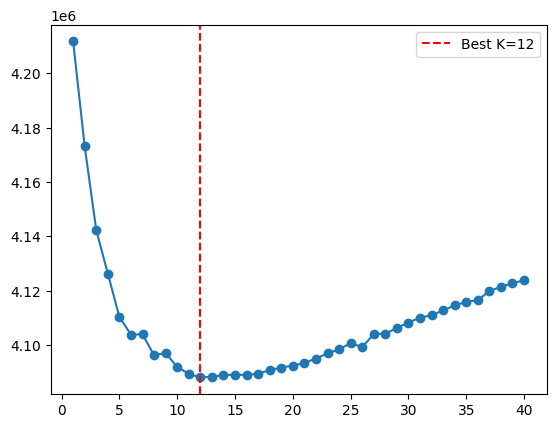

In [13]:
import pickle

with open("../result/bic_results.pkl", "rb") as f:
    bic_results = pickle.load(f)

plt.plot(range(1, len(bic_results["bics"])+1), bic_results["bics"], marker='o')
plt.axvline(best_K, color='r', linestyle='--', label=f'Best K={bic_results["best_K"]}')
plt.legend()


# Analyses

In [26]:
import pandas as pd
clustered_df = pd.read_csv("../result/item_clusters.csv")

In [47]:
clustered_df['item'].shape

(78712,)

In [54]:
a_cluster = pd.Series(clustered_df['cluster'].values, index=a_df.index, name='cluster')
a_cluster

input.text                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

In [ ]:
import numpy as np

# Step 1: Assemble your a-parameter matrix (A)
# Let's assume you have 4 math items and a 3-dimensional MIRT model.
# Shape: (num_items, num_dimensions)
a_matrix = np.array([
    [0.8, 0.2, 0.1],  # Item 1 a-parameters
    [0.9, 0.1, 0.3],  # Item 2 a-parameters
    [0.7, 0.3, 0.2],  # Item 3 a-parameters
    [0.85, 0.25, 0.15] # Item 4 a-parameters
])

# Step 2: Compute the A'A matrix (transpose of A multiplied by A)
a_transpose = a_matrix.T
ata_matrix = a_transpose.dot(a_matrix)

print("## A'A Matrix (3x3):")
print(ata_matrix)

# Step 3: Perform eigendecomposition
eigenvalues, eigenvectors = np.linalg.eig(ata_matrix)

print("\n## Eigenvalues:")
print(eigenvalues)

print("\n## Eigenvectors (each column is an eigenvector):")
print(eigenvectors)

# Step 4: Identify the eigenvector for the largest eigenvalue
# Find the index of the largest eigenvalue
max_eigenvalue_index = np.argmax(eigenvalues)

# Get the corresponding eigenvector
reference_composite = eigenvectors[:, max_eigenvalue_index]

# It's good practice to normalize it to a unit vector (length of 1)
reference_composite_unit_vector = reference_composite / np.linalg.norm(reference_composite)

print(f"\n## The Reference Composite (Eigenvector for largest eigenvalue λ = {eigenvalues[max_eigenvalue_index]:.2f}):")
print(reference_composite_unit_vector)

In [57]:
# Create a_cluster_dims dataframe combining cluster info with 19 dimensions
a_cluster_dims = a_df.copy()
a_cluster_dims['cluster'] = a_cluster
print(f"Shape of a_cluster_dims: {a_cluster_dims.shape}")
print(f"Columns: {list(a_cluster_dims.columns)}")
print("\nCluster distribution:")
print(a_cluster_dims['cluster'].value_counts().sort_index())


Shape of a_cluster_dims: (78712, 20)
Columns: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 'cluster']

Cluster distribution:
cluster
0     13427
1      9107
2      6191
3      6064
4      5195
5      2900
6      7304
7      3934
8      8941
9      5701
10     2741
11     7207
Name: count, dtype: int64


In [58]:
# Perform eigenvector extraction for each cluster
def extract_reference_composite(a_matrix):
    """
    Extract the reference composite (dominant eigenvector) from a-parameter matrix
    
    Parameters:
    a_matrix: numpy array of shape (num_items, num_dimensions)
    
    Returns:
    dict with eigenvalues, eigenvectors, and reference composite
    """
    if len(a_matrix) == 0:
        return None
        
    # Step 1: Compute A'A matrix
    a_transpose = a_matrix.T
    ata_matrix = a_transpose.dot(a_matrix)
    
    # Step 2: Perform eigendecomposition
    eigenvalues, eigenvectors = np.linalg.eig(ata_matrix)
    
    # Step 3: Get dominant eigenvector (largest eigenvalue)
    max_eigenvalue_index = np.argmax(eigenvalues)
    reference_composite = eigenvectors[:, max_eigenvalue_index]
    
    # Normalize to unit vector
    reference_composite_unit = reference_composite / np.linalg.norm(reference_composite)
    
    return {
        'eigenvalues': eigenvalues,
        'eigenvectors': eigenvectors,
        'max_eigenvalue': eigenvalues[max_eigenvalue_index],
        'reference_composite': reference_composite_unit,
        'ata_matrix': ata_matrix
    }

# Extract reference composite for each cluster
cluster_results = {}
cluster_summaries = []

print("Extracting reference composites for each cluster:\n")

for cluster_id in sorted(a_cluster_dims['cluster'].unique()):
    # Get items in this cluster
    cluster_items = a_cluster_dims[a_cluster_dims['cluster'] == cluster_id]
    
    # Extract just the a-parameters (exclude the cluster column)
    a_params = cluster_items.iloc[:, :-1].values  # All columns except 'cluster'
    
    print(f"Cluster {cluster_id}: {len(cluster_items)} items")
    
    # Extract reference composite
    result = extract_reference_composite(a_params)
    
    if result is not None:
        cluster_results[cluster_id] = result
        
        # Create summary
        summary = {
            'cluster': cluster_id,
            'num_items': len(cluster_items),
            'max_eigenvalue': result['max_eigenvalue'].real,
            'reference_composite': result['reference_composite'].real
        }
        cluster_summaries.append(summary)
        
        print(f"  Max eigenvalue: {result['max_eigenvalue'].real:.3f}")
        print(f"  Reference composite (first 5 dims): {result['reference_composite'].real[:5]}")
    else:
        print(f"  No items in cluster {cluster_id}")
    print()


Extracting reference composites for each cluster:

Cluster 0: 13427 items
  Max eigenvalue: 6040.863
  Reference composite (first 5 dims): [-0.38447144  0.2435184   0.01975797 -0.00316209  0.05653641]

Cluster 1: 9107 items
  Max eigenvalue: 17954.060
  Reference composite (first 5 dims): [ 0.10989675  0.04059182 -0.00925265 -0.01297629 -0.06965072]

Cluster 2: 6191 items
  Max eigenvalue: 6431.397
  Reference composite (first 5 dims): [-0.06397456 -0.13049718  0.00922242  0.00389428  0.04746614]

Cluster 3: 6064 items
  Max eigenvalue: 11890.621
  Reference composite (first 5 dims): [ 0.1708868   0.0061718  -0.00303077  0.0165389   0.45124178]

Cluster 4: 5195 items
  Max eigenvalue: 8167.557
  Reference composite (first 5 dims): [ 0.15018087 -0.17989192 -0.01167215  0.00427274 -0.0388595 ]

Cluster 5: 2900 items
  Max eigenvalue: 9366.701
  Reference composite (first 5 dims): [ 0.98753093 -0.02086679 -0.00139837 -0.00261813 -0.01909875]

Cluster 6: 7304 items
  Max eigenvalue: 13191.

In [59]:
# Create comprehensive summary dataframes
print("Creating summary dataframes...\n")

# 1. Cluster summary with basic stats
cluster_summary_df = pd.DataFrame(cluster_summaries)
print("Cluster Summary:")
print(cluster_summary_df.to_string(index=False))
print()

# 2. Reference composites as a dataframe (each cluster as a row)
ref_composites = []
for cluster_id in sorted(cluster_results.keys()):
    row = {'cluster': cluster_id}
    ref_comp = cluster_results[cluster_id]['reference_composite'].real
    for dim in range(len(ref_comp)):
        row[f'dim_{dim}'] = ref_comp[dim]
    ref_composites.append(row)

reference_composites_df = pd.DataFrame(ref_composites)
print("Reference Composites (first 5 dimensions shown):")
cols_to_show = ['cluster'] + [f'dim_{i}' for i in range(5)]
print(reference_composites_df[cols_to_show].to_string(index=False))
print()

# 3. Show eigenvalue distribution
eigenvalues_by_cluster = {cluster_id: results['eigenvalues'].real 
                         for cluster_id, results in cluster_results.items()}

print("Eigenvalues per cluster (first 5 shown):")
for cluster_id in sorted(eigenvalues_by_cluster.keys())[:5]:
    evals = eigenvalues_by_cluster[cluster_id]
    print(f"Cluster {cluster_id}: {evals[:5]}")
print()


Creating summary dataframes...

Cluster Summary:
 cluster  num_items  max_eigenvalue                                                                                                                                                                                                                                                                                                                                                                                                                           reference_composite
       0      13427     6040.863291                [-0.3844714420094725, 0.2435183969544596, 0.019757974039402302, -0.003162093469849175, 0.05653641201093504, 0.06111706594461436, 0.008262229349613535, -0.025442717071803646, -0.38153261252795617, -0.02194078972681617, 0.1756640105731844, -0.0017563361195762483, -0.6419803427953951, 0.015021007216568905, -0.004234077112285861, -0.011487579266920261, -0.4409235191651579, 0.023524536025499768, 0.02102778401298219]
       1       9107

In [60]:
# Save results to files
print("Saving results to files...")

# Save the cluster dimensions dataframe
a_cluster_dims.to_csv("../result/a_cluster_dims.csv")
print("✓ Saved a_cluster_dims to ../result/a_cluster_dims.csv")

# Save cluster summary
cluster_summary_df.to_csv("../result/cluster_summary.csv", index=False)
print("✓ Saved cluster summary to ../result/cluster_summary.csv")

# Save reference composites
reference_composites_df.to_csv("../result/cluster_reference_composites.csv", index=False)
print("✓ Saved reference composites to ../result/cluster_reference_composites.csv")

# Save detailed results as pickle for further analysis
import pickle
with open("../result/cluster_eigenvector_results.pkl", "wb") as f:
    pickle.dump(cluster_results, f)
print("✓ Saved detailed results to ../result/cluster_eigenvector_results.pkl")

print(f"\nComplete! Processed {len(cluster_results)} clusters with eigenvector extraction.")
print(f"Total items processed: {len(a_cluster_dims)}")
print(f"19 dimensions analyzed for each cluster's reference composite.")


Saving results to files...
✓ Saved a_cluster_dims to ../result/a_cluster_dims.csv
✓ Saved cluster summary to ../result/cluster_summary.csv
✓ Saved reference composites to ../result/cluster_reference_composites.csv
✓ Saved detailed results to ../result/cluster_eigenvector_results.pkl

Complete! Processed 12 clusters with eigenvector extraction.
Total items processed: 78712
19 dimensions analyzed for each cluster's reference composite.


In [61]:
import numpy as np
import pandas as pd

# Assume 'theta_df' from your previous cell is already loaded.
# It has the shape (183 models, 19 dimensions).

# --- Step 1: Assemble Your Projection Matrix ---
# Load the reference composites you saved in the previous step.
# This ensures you can run this cell independently later.
reference_composites_df = pd.read_csv("../result/cluster_reference_composites.csv")

# Sort by cluster to ensure the order is consistent (0, 1, 2, ...)
reference_composites_df = reference_composites_df.sort_values('cluster').reset_index(drop=True)

# Extract the 19-dimensional eigenvectors into a NumPy matrix.
# This will be our projection matrix. Shape: (12 clusters, 19 dimensions)
projection_matrix = reference_composites_df.filter(regex='^dim_').values


# --- Step 2: Project Abilities onto Constructs ---
# Get the theta matrix as a NumPy array. Shape: (183 models, 19 dimensions)
theta_matrix = theta_df.values

# Project the thetas onto the reference composites via dot product.
# The operation is: (183, 19) • (19, 12) -> (183, 12)
# We transpose the projection_matrix to get the correct shape for the dot product.
multidimensional_scores = theta_matrix.dot(projection_matrix.T)


# --- Step 3: Create the Final, Interpretable DataFrame ---
# It's highly recommended to give meaningful names to your clusters by
# inspecting the content of the items within each one.
# For now, we'll create generic names.
score_columns = [f"Capability_Cluster_{i}" for i in range(projection_matrix.shape[0])]

# Create the final DataFrame
scores_df = pd.DataFrame(
    multidimensional_scores,
    index=theta_df.index,
    columns=score_columns
)

print("--- Multidimensional Scores on 12 Capabilities ---")
print(scores_df.head())

# Save the final scores to a new file
scores_df.to_csv("../result/model_capability_scores.csv")
print("\n✓ Scores saved to ../result/model_capability_scores.csv")

--- Multidimensional Scores on 12 Capabilities ---
                                  Capability_Cluster_0  Capability_Cluster_1  \
request.model                                                                  
together/t0pp                                -1.342001             -0.066648   
aisingapore/sea-lion-7b-instruct             -0.933711             -0.728537   
eleutherai/pythia-1b-v0                      -1.853293              0.690976   
allenai/olmo-7b                              -1.206349              1.137183   
together/opt-66b                             -1.386689             -3.728042   

                                  Capability_Cluster_2  Capability_Cluster_3  \
request.model                                                                  
together/t0pp                                 1.028616              1.898104   
aisingapore/sea-lion-7b-instruct             -0.408992              0.907606   
eleutherai/pythia-1b-v0                       1.082789             -

/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_68058/2353694011.py:109: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


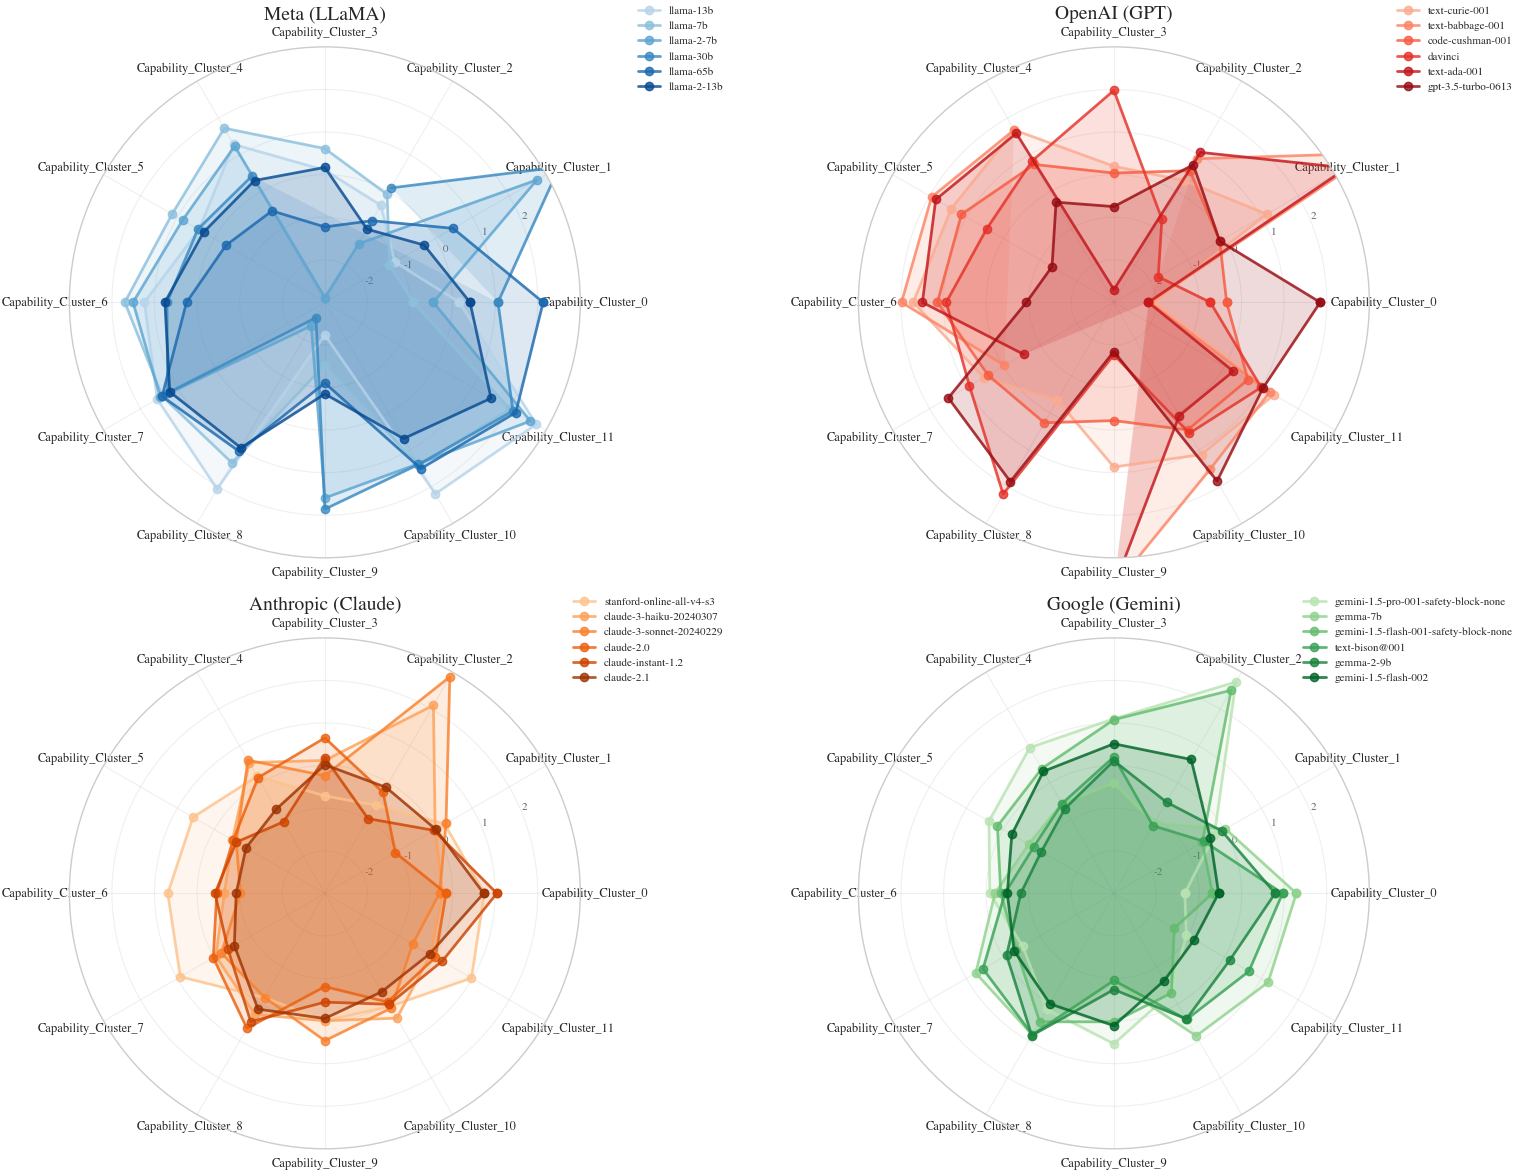

/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_68058/2353694011.py:161: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


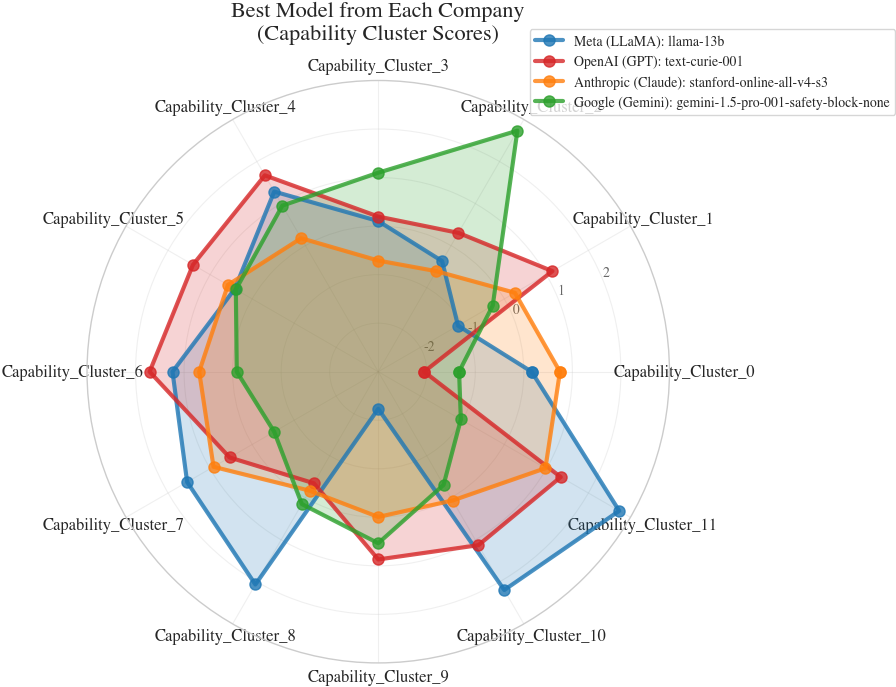

Saved:
 - ../result/model_families_capability_radar_charts.pdf
 - ../result/best_models_capabilities_composite_radar_chart.pdf


In [62]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from math import pi

# Load scores if not already in memory
try:
    _ = scores_df
except NameError:
    scores_df = pd.read_csv("../result/model_capability_scores.csv", index_col=0)

# Labels are capability cluster columns from the projection step
capability_labels = list(scores_df.columns)

# Radar chart helper

def create_radar_chart(data, labels, title, ax, colors=None, model_names=None):
    """
    Create a radar chart for given data
    - data: 2D array-like (n_models x n_labels)
    - labels: list[str]
    - title: str
    - ax: matplotlib Axes with projection='polar'
    - colors: iterable of RGBA colors
    - model_names: iterable of names for legend
    """
    N = len(labels)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]

    if colors is None:
        colors = plt.cm.tab10(np.linspace(0, 1, len(data)))

    for i, (model_data, color) in enumerate(zip(data, colors)):
        values = model_data.tolist()
        values += values[:1]

        model_name = model_names[i] if model_names else f'Model {i+1}'
        display_name = model_name.split('/')[-1] if '/' in model_name else model_name

        ax.plot(angles, values, 'o-', linewidth=2, label=display_name, color=color, alpha=0.8)
        ax.fill(angles, values, color=color, alpha=0.15)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=9, weight='bold')
    ax.set_ylim(-3, 3)
    ax.set_title(title, size=14, weight='bold', pad=20)
    ax.grid(True, alpha=0.3)

    ax.set_yticks([-2, -1, 0, 1, 2])
    ax.set_yticklabels(['-2', '-1', '0', '1', '2'], fontsize=8, alpha=0.7)

# Group models by company prefix
companies = {
    'meta': [],
    'openai': [],
    'anthropic': [],
    'google': []
}

common_models = scores_df.dropna().index
for model in common_models:
    if model.startswith('meta/'):
        companies['meta'].append(model)
    elif model.startswith('openai/'):
        companies['openai'].append(model)
    elif model.startswith('anthropic/'):
        companies['anthropic'].append(model)
    elif model.startswith('google/'):
        companies['google'].append(model)

# Select top models per company by mean capability score

def select_top_models(models, n=6):
    if not models:
        return []
    model_scores = scores_df.loc[models].mean(axis=1).sort_values(ascending=False)
    return model_scores.head(n).index.tolist()

selected_models = {company: select_top_models(models, n=6) for company, models in companies.items()}

# Per-company radar charts
fig, axes = plt.subplots(2, 2, figsize=(16, 12), subplot_kw=dict(projection='polar'))
axes = axes.flatten()

company_names = ['Meta (LLaMA)', 'OpenAI (GPT)', 'Anthropic (Claude)', 'Google (Gemini)']
company_keys = ['meta', 'openai', 'anthropic', 'google']

for i, (company_key, company_name) in enumerate(zip(company_keys, company_names)):
    models = selected_models[company_key]
    if models:
        model_data = scores_df.loc[models, capability_labels].values

        if company_key == 'meta':
            colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(models)))
        elif company_key == 'openai':
            colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(models)))
        elif company_key == 'anthropic':
            colors = plt.cm.Oranges(np.linspace(0.3, 0.9, len(models)))
        else:
            colors = plt.cm.Greens(np.linspace(0.3, 0.9, len(models)))

        create_radar_chart(model_data, capability_labels, company_name, axes[i], colors=colors, model_names=models)
        axes[i].legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)
    else:
        axes[i].text(0.5, 0.5, f'No {company_name} models found', transform=axes[i].transAxes, ha='center', va='center')
        axes[i].set_title(company_name, size=14, weight='bold', pad=20)

plt.tight_layout()
plt.savefig('../result/model_families_capability_radar_charts.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Composite radar chart for best model from each company
best_models = {}
company_colors = {
    'meta': '#1f77b4',
    'openai': '#d62728',
    'anthropic': '#ff7f0e',
    'google': '#2ca02c'
}
company_full_names = {
    'meta': 'Meta (LLaMA)',
    'openai': 'OpenAI (GPT)',
    'anthropic': 'Anthropic (Claude)',
    'google': 'Google (Gemini)'
}

for company, models in companies.items():
    if models:
        best_model = scores_df.loc[models].mean(axis=1).idxmax()
        best_models[company] = best_model

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
N = len(capability_labels)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

for company, model in best_models.items():
    if model in scores_df.index:
        values = scores_df.loc[model, capability_labels].tolist()
        values += values[:1]

        display_name = model.split('/')[-1]
        company_name = company_full_names[company]
        legend_label = f"{company_name}: {display_name}"

        ax.plot(angles, values, 'o-', linewidth=3, label=legend_label, color=company_colors[company], alpha=0.8, markersize=8)
        ax.fill(angles, values, color=company_colors[company], alpha=0.2)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(capability_labels, fontsize=12, weight='bold')
ax.set_ylim(-3, 3)
ax.set_title('Best Model from Each Company\n(Capability Cluster Scores)', size=16, weight='bold', pad=30)
ax.grid(True, alpha=0.3)

ax.set_yticks([-2, -1, 0, 1, 2])
ax.set_yticklabels(['-2', '-1', '0', '1', '2'], fontsize=10, alpha=0.7)

ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1), fontsize=10, frameon=True)

plt.tight_layout()
plt.savefig('../result/best_models_capabilities_composite_radar_chart.pdf', bbox_inches='tight', dpi=300)
plt.show()

print("Saved:\n - ../result/model_families_capability_radar_charts.pdf\n - ../result/best_models_capabilities_composite_radar_chart.pdf")
